In [17]:
!pip install pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]


In [16]:
import os
import pandas as pd
import json

current_dir = '/Users/tzhou/Documents/Github/WebDomainRandomizer'
os.chdir(current_dir)
print(f"Current working directory changed to: {os.getcwd()}")

data_dir = os.path.join(current_dir, 'uitars_results')
experiment_folders = os.listdir(data_dir)

print(f"Contents of '{data_dir}': {experiment_folders}")

variant_results = {}

for variant_folder in experiment_folders:
    data_root = os.path.join(data_dir, variant_folder)

    if not os.path.isdir(data_root):
        continue

    variant_results[variant_folder] = {}
    
    num_episodes = 0
    num_steps = 0
    action_str_em = 0
    hit_box_accuracy = 0
    bbox_center_mse = 0

    for run_folder in os.listdir(data_root):
        if not os.path.isdir(os.path.join(data_root, run_folder)):
            continue

        summary_file = os.path.join(data_root, run_folder, "uitars_summary.json")

        if not os.path.isfile(summary_file):
            print(f"Warning: Missing {summary_file}")
            continue

        with open(summary_file, "r") as f:
            data = json.load(f)

        # print("=" * 80)
        # print(f"Run: {run_folder}")
        # pprint(data['global'])
        # print("=" * 80)

        if run_folder.split("_")[-1] == "original":
            num_episodes += data['global']['num_episodes']
            action_str_em = (num_steps * action_str_em + data['global']['metrics']['action_str_em']['mean'] * data['global']['metrics']['action_str_em']['count']) / (num_steps + data['global']['metrics']['action_str_em']['count'])
            hit_box_accuracy = (num_steps * hit_box_accuracy + data['global']['metrics']['hit_box_accuracy']['mean'] * data['global']['metrics']['hit_box_accuracy']['count']) / (num_steps + data['global']['metrics']['hit_box_accuracy']['count'])
            bbox_center_mse = (num_steps * bbox_center_mse + data['global']['metrics']['bbox_center_mse']['mean'] * data['global']['metrics']['bbox_center_mse']['count']) / (num_steps + data['global']['metrics']['bbox_center_mse']['count'])
            num_steps += data['global']['num_steps']
    
            variant_results[variant_folder]["original"] = {
                "num_episodes": num_episodes,
                "num_steps": num_steps,
                "action_str_em": action_str_em,
                "hit_box_accuracy": hit_box_accuracy,
                "bbox_center_mse": bbox_center_mse
            }
        elif run_folder.split("_")[-1] == "precision":
            num_episodes += data['global']['num_episodes']
            num_steps += data['global']['num_steps']
            action_str_em = (num_steps * action_str_em + data['global']['metrics']['action_str_em']['mean'] * data['global']['metrics']['action_str_em']['count']) / (num_steps + data['global']['metrics']['action_str_em']['count'])
            hit_box_accuracy = (num_steps * hit_box_accuracy + data['global']['metrics']['hit_box_accuracy']['mean'] * data['global']['metrics']['hit_box_accuracy']['count']) / (num_steps + data['global']['metrics']['hit_box_accuracy']['count'])
            bbox_center_mse = (num_steps * bbox_center_mse + data['global']['metrics']['bbox_center_mse']['mean'] * data['global']['metrics']['bbox_center_mse']['count']) / (num_steps + data['global']['metrics']['bbox_center_mse']['count'])

            variant_results[variant_folder]["precision"] = {
                "num_episodes": num_episodes,
                "num_steps": num_steps,
                "action_str_em": action_str_em,
                "hit_box_accuracy": hit_box_accuracy,
                "bbox_center_mse": bbox_center_mse
            }
        elif run_folder.split("_")[-1] == "shrink":
            num_episodes += data['global']['num_episodes']
            num_steps += data['global']['num_steps']
            action_str_em = (num_steps * action_str_em + data['global']['metrics']['action_str_em']['mean'] * data['global']['metrics']['action_str_em']['count']) / (num_steps + data['global']['metrics']['action_str_em']['count'])
            hit_box_accuracy = (num_steps * hit_box_accuracy + data['global']['metrics']['hit_box_accuracy']['mean'] * data['global']['metrics']['hit_box_accuracy']['count']) / (num_steps + data['global']['metrics']['hit_box_accuracy']['count'])
            bbox_center_mse = (num_steps * bbox_center_mse + data['global']['metrics']['bbox_center_mse']['mean'] * data['global']['metrics']['bbox_center_mse']['count']) / (num_steps + data['global']['metrics']['bbox_center_mse']['count'])

            variant_results[variant_folder]["text_shrink"] = {
                "num_episodes": num_episodes,
                "num_steps": num_steps,
                "action_str_em": action_str_em,
                "hit_box_accuracy": hit_box_accuracy,
                "bbox_center_mse": bbox_center_mse
            }
        elif run_folder.split("_")[-1] == "style":
            num_episodes += data['global']['num_episodes']
            num_steps += data['global']['num_steps']
            action_str_em = (num_steps * action_str_em + data['global']['metrics']['action_str_em']['mean'] * data['global']['metrics']['action_str_em']['count']) / (num_steps + data['global']['metrics']['action_str_em']['count'])
            hit_box_accuracy = (num_steps * hit_box_accuracy + data['global']['metrics']['hit_box_accuracy']['mean'] * data['global']['metrics']['hit_box_accuracy']['count']) / (num_steps + data['global']['metrics']['hit_box_accuracy']['count'])
            bbox_center_mse = (num_steps * bbox_center_mse + data['global']['metrics']['bbox_center_mse']['mean'] * data['global']['metrics']['bbox_center_mse']['count']) / (num_steps + data['global']['metrics']['bbox_center_mse']['count'])

            variant_results[variant_folder]["style"] = {
                "num_episodes": num_episodes,
                "num_steps": num_steps,
                "action_str_em": action_str_em,
                "hit_box_accuracy": hit_box_accuracy,
                "bbox_center_mse": bbox_center_mse
            }


with open("variant_results.json", "w") as f:
    json.dump(variant_results, f, indent=4, sort_keys=True)
    print(json.dumps(variant_results, indent=4))

Current working directory changed to: /Users/tzhou/Documents/Github/WebDomainRandomizer
Contents of '/Users/tzhou/Documents/Github/WebDomainRandomizer/uitars_results': ['locke_uitars_NO_thought_relational_query', 'locke_uitars_thought_direct_query', 'locke_uitars_thought_relational_query', 'locke_uitars_NO_thought_direct_query']
{
    "locke_uitars_NO_thought_relational_query": {
        "text_shrink": {
            "num_episodes": 1216,
            "num_steps": 1184,
            "action_str_em": 0.71212026607404,
            "hit_box_accuracy": 0.15059970475970855,
            "bbox_center_mse": 106958.52757672704
        },
        "original": {
            "num_episodes": 836,
            "num_steps": 824,
            "action_str_em": 0.6785958730368082,
            "hit_box_accuracy": 0.14975174035603228,
            "bbox_center_mse": 108041.12873022034
        },
        "precision": {
            "num_episodes": 940,
            "num_steps": 952,
            "action_str_em": 0.6

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

variant_results = json.load(open("variant_results.json"))
# Prepare data for visualization
def parse_model_name(name):
    """Parse model name into components"""
    parts = name.split('_')
    model = parts[1]  # gta1, qwen, or uitars
    has_thought = 'NO' not in name
    query_type = 'relational' if 'relational' in name else 'direct'
    return {
        'model': model,
        'has_thought': has_thought,
        'query_type': query_type,
        'full_name': name
    }

# Create DataFrame for easier plotting
data_rows = []
for model_name, variants in variant_results.items():
    model_info = parse_model_name(model_name)
    for variant_name, metrics in variants.items():
        row = {
            'model': model_info['model'],
            'has_thought': model_info['has_thought'],
            'query_type': model_info['query_type'],
            'full_name': model_info['full_name'],
            'variant': variant_name,
            **metrics
        }
        data_rows.append(row)

df = pd.DataFrame(data_rows)
print(f"Data shape: {df.shape}")
print(f"\nModels: {df['model'].unique()}")
print(f"Variants: {df['variant'].unique()}")
print(f"\nFirst few rows:")
df.head(10)

Data shape: (16, 10)

Models: ['uitars']
Variants: ['original' 'precision' 'style' 'text_shrink']

First few rows:


,model,has_thought,query_type,full_name,variant,action_str_em,bbox_center_mse,hit_box_accuracy,num_episodes,num_steps
0,uitars,False,direct,locke_uitars_NO_thought_direct_query,original,0.713642,91576.349557,0.453933,836,824
1,uitars,False,direct,locke_uitars_NO_thought_direct_query,precision,0.724432,91649.142326,0.454763,940,952
2,uitars,False,direct,locke_uitars_NO_thought_direct_query,style,0.737073,91352.866061,0.462573,1078,1068
3,uitars,False,direct,locke_uitars_NO_thought_direct_query,text_shrink,0.748226,91390.579142,0.471298,1216,1184
4,uitars,False,relational,locke_uitars_NO_thought_relational_query,original,0.678596,108041.128730,0.149752,836,824
5,uitars,False,relational,locke_uitars_NO_thought_relational_query,precision,0.688910,106897.109347,0.148670,940,952
6,uitars,False,relational,locke_uitars_NO_thought_relational_query,style,0.700808,107222.165890,0.153530,1078,1068
7,uitars,False,relational,locke_uitars_NO_thought_relational_query,text_shrink,0.712120,106958.527577,0.150600,1216,1184
8,uitars,True,direct,locke_uitars_thought_direct_query,original,0.653551,77309.376988,0.459656,836,824
9,uitars,True,direct,locke_uitars_thought_direct_query,precision,0.660353,75961.274072,0.465911,940,952


## Impact of Variant on action string matching, bounding box mse, and hit box accuracy

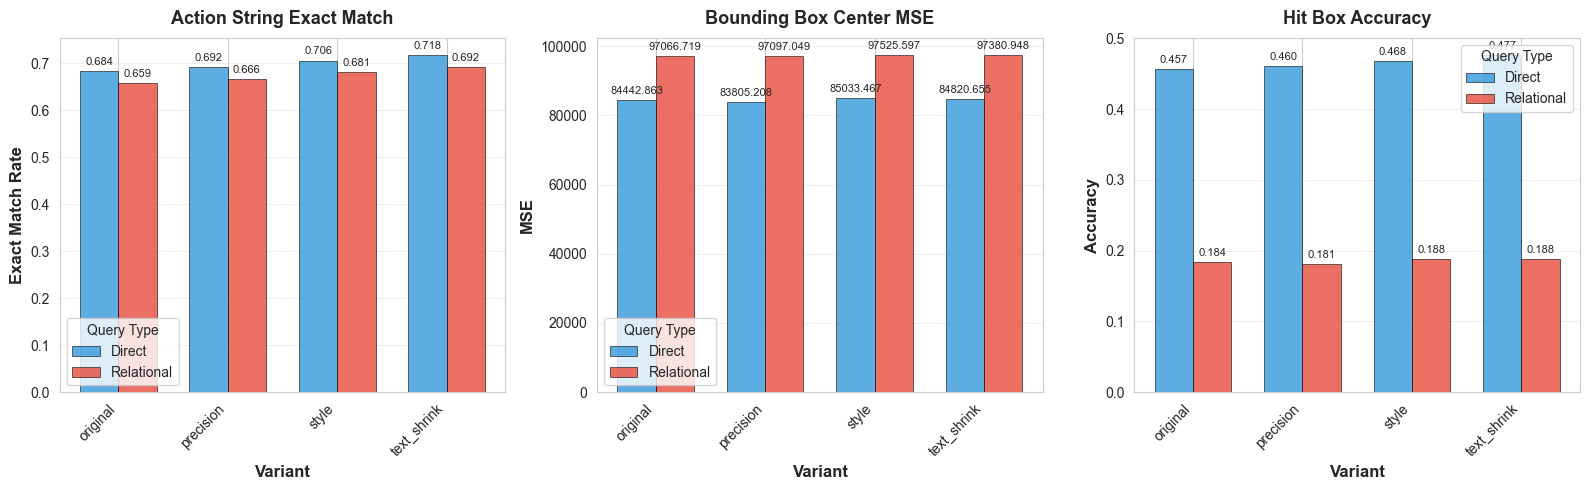


SUMMARY STATISTICS BY QUERY TYPE

ACTION_STR_EM:
                mean       std       min       max
query_type                                        
direct      0.700123  0.035784  0.653551  0.748226
relational  0.674579  0.025983  0.638607  0.712120

BBOX_CENTER_MSE:
                    mean           std           min            max
query_type                                                         
direct      84525.548411   7490.630932  75961.274072   91649.142326
relational  97267.578235  10722.222347  86092.309553  108041.128730

HIT_BOX_ACCURACY:
                mean       std       min       max
query_type                                        
direct      0.465365  0.009678  0.453933  0.482253
relational  0.185093  0.036999  0.148670  0.224985


In [20]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define colors for query types
colors = {'direct': '#3498db', 'relational': '#e74c3c'}

# Metrics to plot
metrics = ['action_str_em', 'bbox_center_mse', 'hit_box_accuracy']
titles = ['Action String Exact Match', 'Bounding Box Center MSE', 'Hit Box Accuracy']
ylabels = ['Exact Match Rate', 'MSE', 'Accuracy']

# For each metric, create a grouped bar chart
for idx, (metric, title, ylabel) in enumerate(zip(metrics, titles, ylabels)):
    ax = axes[idx]
    
    # Group by query_type and variant
    grouped = df.groupby(['query_type', 'variant'])[metric].mean().reset_index()
    
    # Get unique variants
    variants = grouped['variant'].unique()
    x = np.arange(len(variants))
    width = 0.35
    
    # Plot bars for each query type
    for i, query_type in enumerate(['direct', 'relational']):
        data = grouped[grouped['query_type'] == query_type]
        values = [data[data['variant'] == v][metric].values[0] if v in data['variant'].values else 0 
                  for v in variants]
        offset = width * (i - 0.5)
        ax.bar(x + offset, values, width, label=query_type.capitalize(), 
               color=colors[query_type], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize subplot
    ax.set_xlabel('Variant', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=45, ha='right')
    ax.legend(title='Query Type', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('query_type_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS BY QUERY TYPE")
print("="*80)
for metric in metrics:
    print(f"\n{metric.upper()}:")
    summary = df.groupby('query_type')[metric].agg(['mean', 'std', 'min', 'max'])
    print(summary)

## Thinking vs Non Thinking Performance

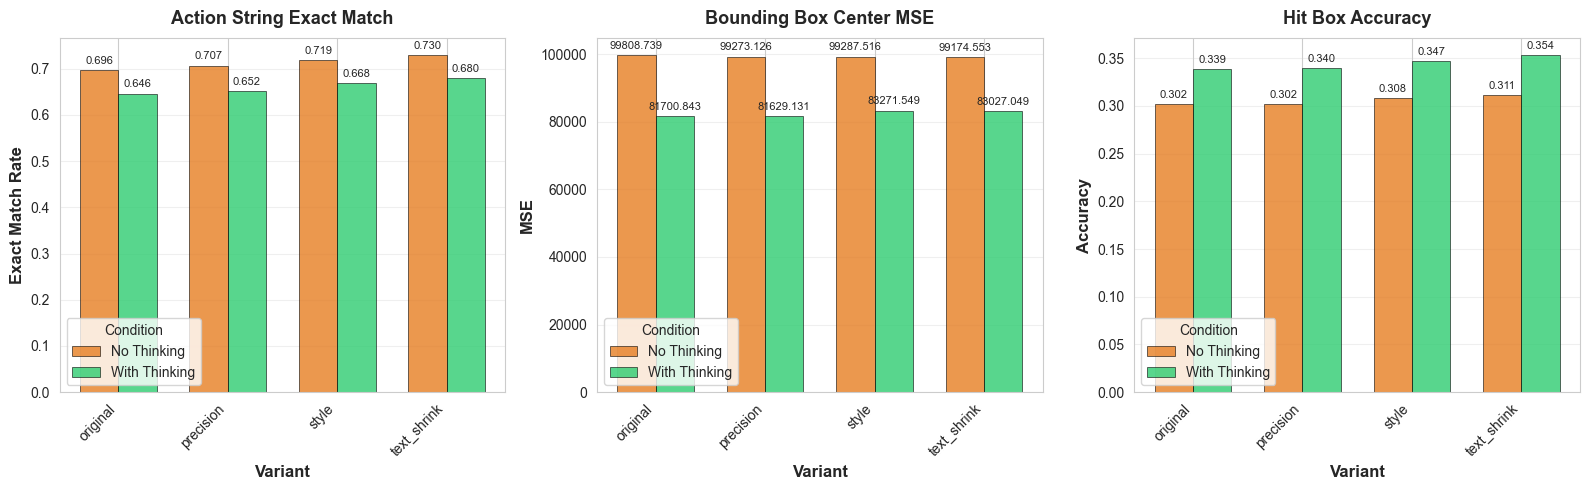


SUMMARY STATISTICS: THINKING vs NO THINKING

ACTION_STR_EM:
                   mean       std       min       max
No Thinking    0.712976  0.023497  0.678596  0.748226
With Thinking  0.661726  0.016598  0.638607  0.688659
  → Performance Gain: -7.19%

BBOX_CENTER_MSE:
                       mean          std           min            max
No Thinking    99385.983579  8446.337237  91352.866061  108041.128730
With Thinking  82407.143067  5270.648285  75961.274072   87829.028324
  → MSE Reduction: 17.08%

HIT_BOX_ACCURACY:
                   mean       std      min       max
No Thinking    0.305640  0.165794  0.14867  0.471298
With Thinking  0.344819  0.134107  0.21379  0.482253
  → Performance Gain: 12.82%



In [21]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define colors for thinking conditions
colors = {True: '#2ecc71', False: '#e67e22'}  # Green for thinking, Orange for no thinking
labels = {True: 'With Thinking', False: 'No Thinking'}

# Metrics to plot
metrics = ['action_str_em', 'bbox_center_mse', 'hit_box_accuracy']
titles = ['Action String Exact Match', 'Bounding Box Center MSE', 'Hit Box Accuracy']
ylabels = ['Exact Match Rate', 'MSE', 'Accuracy']

# For each metric, create a grouped bar chart
for idx, (metric, title, ylabel) in enumerate(zip(metrics, titles, ylabels)):
    ax = axes[idx]
    
    # Group by has_thought and variant
    grouped = df.groupby(['has_thought', 'variant'])[metric].mean().reset_index()
    
    # Get unique variants
    variants = grouped['variant'].unique()
    x = np.arange(len(variants))
    width = 0.35
    
    # Plot bars for each thinking condition
    for i, has_thought in enumerate([False, True]):
        data = grouped[grouped['has_thought'] == has_thought]
        values = [data[data['variant'] == v][metric].values[0] if v in data['variant'].values else 0 
                  for v in variants]
        offset = width * (i - 0.5)
        ax.bar(x + offset, values, width, label=labels[has_thought], 
               color=colors[has_thought], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize subplot
    ax.set_xlabel('Variant', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=45, ha='right')
    ax.legend(title='Condition', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('thinking_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS: THINKING vs NO THINKING")
print("="*80)
for metric in metrics:
    print(f"\n{metric.upper()}:")
    summary = df.groupby('has_thought')[metric].agg(['mean', 'std', 'min', 'max'])
    summary.index = ['No Thinking', 'With Thinking']
    print(summary)
    
    # Calculate improvement
    no_think = df[df['has_thought'] == False][metric].mean()
    with_think = df[df['has_thought'] == True][metric].mean()
    
    if 'mse' in metric:  # Lower is better for MSE
        improvement = ((no_think - with_think) / no_think) * 100
        print(f"  → MSE Reduction: {improvement:.2f}%")
    else:  # Higher is better for EM and accuracy
        improvement = ((with_think - no_think) / no_think) * 100
        print(f"  → Performance Gain: {improvement:.2f}%")

print("\n" + "="*80)

## Examining Types of MSE

Average MSE is a little misleading, since if the model identifies the wrong element, it doesn't matter how far the prediction is from the ground truth. Based on the hit box accuracy, we may be able to determine more about MSE. If the hit box is correct, MSE can tell us how close to the target the model got, but if the hit box is obviously missed (predicted action targets the complete wrong thing), then the MSE isn't as useful. 

How can we tell if the model is trying to action the correct item, but just didn't give the correct coordinates?
How can we tell if the model predicted the wrong item? 

The following plots show how MSE and pixel errors are distributed depending on bounding box hit rates. Actual bounding box data is not available in the `uitars_summary.json` files, so this uses pixel error < 100 as a rough estimate of bounding box hit/misses.

In [ ]:
import re
from typing import Tuple, Sequence

def _point_inside_bbox(point: Tuple[float, float], bbox: Sequence[float]) -> bool:
    x, y = point
    if len(bbox) < 4:
        return False
    bx, by, bw, bh = map(float, bbox[:4])
    return bx <= x <= bx + bw and by <= y <= by + bh

step_data_rows_v2 = []

for variant_folder in experiment_folders:
    data_root = os.path.join(data_dir, variant_folder)
    
    if not os.path.isdir(data_root):
        continue
    
    for run_folder in os.listdir(data_root):
        if not os.path.isdir(os.path.join(data_root, run_folder)):
            continue
        
        summary_file = os.path.join(data_root, run_folder, "uitars_summary.json")
        
        if not os.path.isfile(summary_file):
            continue
        
        with open(summary_file, "r") as f:
            data = json.load(f)
        
        # Determine variant type from folder name
        variant_type = run_folder.split("_")[-1]
        
        # Extract step-level data with hit information
        for episode in data.get('episodes', []):
            episode_id = episode['episode']
            
            for step in episode.get('steps', []):
                # Parse ground truth and prediction coordinates
                gt_match = re.search(r'\((\d+),(\d+)\)', step['ground_truth'][0])
                pred_match = re.search(r'\((\d+),(\d+)\)', step['prediction'])
                
                if gt_match and pred_match:
                    gt_x, gt_y = int(gt_match.group(1)), int(gt_match.group(2))
                    pred_x, pred_y = int(pred_match.group(1)), int(pred_match.group(2))
                    
                    # Calculate MSE
                    mse = (pred_x - gt_x)**2 + (pred_y - gt_y)**2
                    pixel_error = np.sqrt(mse)
                    
                    # We'll need to determine hit_box_accuracy by comparing prediction to bounding box
                    # For now, let's use a heuristic: if pixel error < 100, likely a hit
                    # But we should refine this based on actual box dimensions
                    estimated_hit = 1 if pixel_error < 100 else 0
                    
                    step_data_rows_v2.append({
                        'variant_folder': variant_folder,
                        'variant_type': variant_type,
                        'episode': episode_id,
                        'step_index': step['step_index'],
                        'instruction': step['instruction'],
                        'gt_x': gt_x,
                        'gt_y': gt_y,
                        'pred_x': pred_x,
                        'pred_y': pred_y,
                        'mse': mse,
                        'pixel_error': pixel_error,
                        'estimated_hit': estimated_hit
                    })

step_df = pd.DataFrame(step_data_rows_v2)
print(f"Extracted {len(step_df)} steps from all experiments")
print(f"\nMSE Statistics:")
print(step_df['mse'].describe())
print(f"\nPixel Error Statistics:")
print(step_df['pixel_error'].describe())
print(f"\nEstimated Hit Distribution:")
print(step_df['estimated_hit'].value_counts())


Extracted 4548 steps from all experiments

MSE Statistics:
count    4.548000e+03
mean     1.984611e+05
std      4.219916e+05
min      0.000000e+00
25%      2.570000e+02
50%      1.384600e+04
75%      1.890812e+05
max      3.217492e+06
Name: mse, dtype: float64

Pixel Error Statistics:
count    4548.000000
mean      277.590447
std       348.470034
min         0.000000
25%        16.031220
50%       117.669016
75%       434.834724
max      1793.736881
Name: pixel_error, dtype: float64

Estimated Hit Distribution:
estimated_hit
0    2397
1    2151
Name: count, dtype: int64


Hits: 2151, Misses: 2397


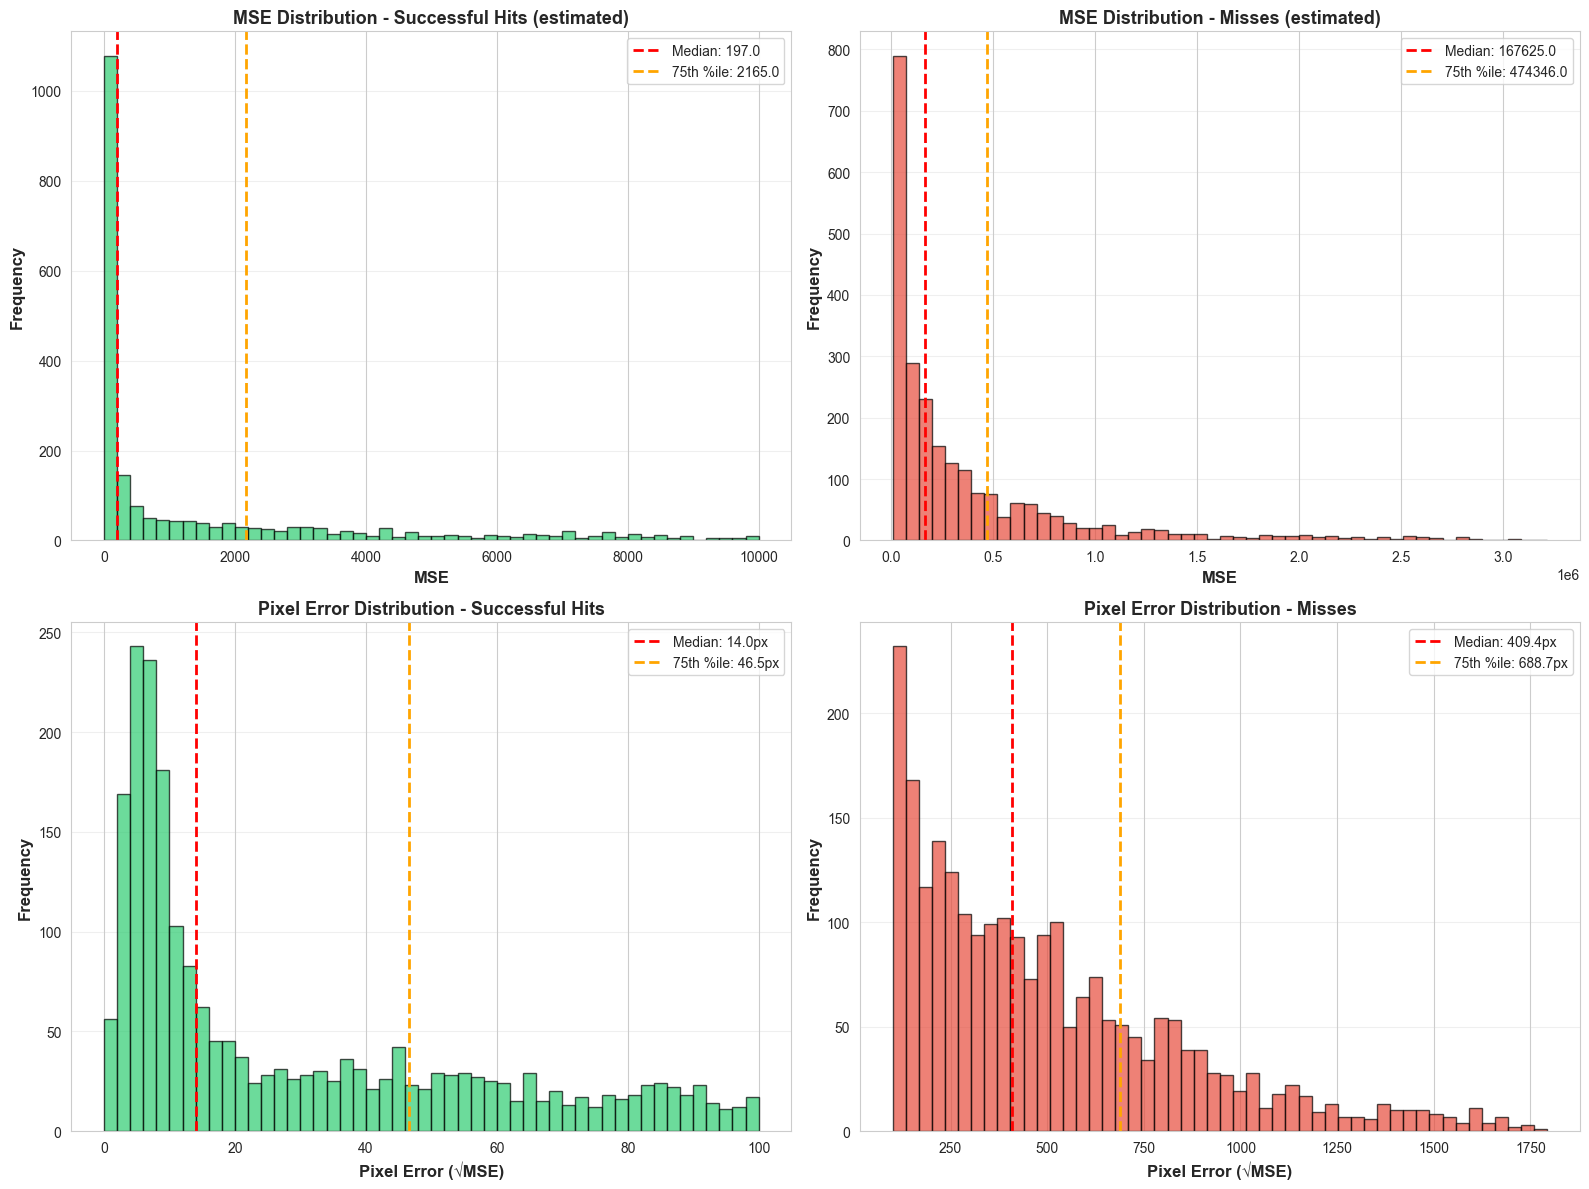


DETAILED MSE STATISTICS - HITS vs MISSES

--- SUCCESSFUL HITS (Estimated) ---
Count: 2151
MSE - Mean: 1560.23, Median: 197.00
MSE - 25th: 41.00, 75th: 2165.00, 90th: 5777.00
Pixel Error - Mean: 28.14px, Median: 14.04px
Pixel Error - 25th: 6.40px, 75th: 46.53px, 90th: 76.01px

--- MISSES ---
Count: 2397
MSE - Mean: 375154.41, Median: 167625.00
MSE - 25th: 50184.00, 75th: 474346.00, 90th: 992509.60
Pixel Error - Mean: 501.44px, Median: 409.42px
Pixel Error - 25th: 224.02px, 75th: 688.73px, 90th: 996.25px



In [28]:
# Visualize MSE distributions separated by hit vs miss
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Separate data by estimated hit
hits_df = step_df[step_df['estimated_hit'] == 1]
misses_df = step_df[step_df['estimated_hit'] == 0]

print(f"Hits: {len(hits_df)}, Misses: {len(misses_df)}")

# 1. MSE Distribution for Hits
ax1 = axes[0, 0]
if len(hits_df) > 0:
    ax1.hist(hits_df['mse'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    ax1.axvline(hits_df['mse'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {hits_df["mse"].median():.1f}')
    ax1.axvline(hits_df['mse'].quantile(0.75), color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {hits_df["mse"].quantile(0.75):.1f}')
    ax1.set_xlabel('MSE', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('MSE Distribution - Successful Hits (estimated)', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

# 2. MSE Distribution for Misses
ax2 = axes[0, 1]
if len(misses_df) > 0:
    ax2.hist(misses_df['mse'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax2.axvline(misses_df['mse'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {misses_df["mse"].median():.1f}')
    ax2.axvline(misses_df['mse'].quantile(0.75), color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {misses_df["mse"].quantile(0.75):.1f}')
    ax2.set_xlabel('MSE', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('MSE Distribution - Misses (estimated)', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

# 3. Pixel Error Distribution for Hits
ax3 = axes[1, 0]
if len(hits_df) > 0:
    ax3.hist(hits_df['pixel_error'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    ax3.axvline(hits_df['pixel_error'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {hits_df["pixel_error"].median():.1f}px')
    ax3.axvline(hits_df['pixel_error'].quantile(0.75), color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {hits_df["pixel_error"].quantile(0.75):.1f}px')
    ax3.set_xlabel('Pixel Error (√MSE)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax3.set_title('Pixel Error Distribution - Successful Hits', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

# 4. Pixel Error Distribution for Misses
ax4 = axes[1, 1]
if len(misses_df) > 0:
    ax4.hist(misses_df['pixel_error'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax4.axvline(misses_df['pixel_error'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {misses_df["pixel_error"].median():.1f}px')
    ax4.axvline(misses_df['pixel_error'].quantile(0.75), color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {misses_df["pixel_error"].quantile(0.75):.1f}px')
    ax4.set_xlabel('Pixel Error (√MSE)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax4.set_title('Pixel Error Distribution - Misses', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mse_distribution_hit_vs_miss.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("DETAILED MSE STATISTICS - HITS vs MISSES")
print("="*80)

print("\n--- SUCCESSFUL HITS (Estimated) ---")
if len(hits_df) > 0:
    print(f"Count: {len(hits_df)}")
    print(f"MSE - Mean: {hits_df['mse'].mean():.2f}, Median: {hits_df['mse'].median():.2f}")
    print(f"MSE - 25th: {hits_df['mse'].quantile(0.25):.2f}, 75th: {hits_df['mse'].quantile(0.75):.2f}, 90th: {hits_df['mse'].quantile(0.90):.2f}")
    print(f"Pixel Error - Mean: {hits_df['pixel_error'].mean():.2f}px, Median: {hits_df['pixel_error'].median():.2f}px")
    print(f"Pixel Error - 25th: {hits_df['pixel_error'].quantile(0.25):.2f}px, 75th: {hits_df['pixel_error'].quantile(0.75):.2f}px, 90th: {hits_df['pixel_error'].quantile(0.90):.2f}px")

print("\n--- MISSES ---")
if len(misses_df) > 0:
    print(f"Count: {len(misses_df)}")
    print(f"MSE - Mean: {misses_df['mse'].mean():.2f}, Median: {misses_df['mse'].median():.2f}")
    print(f"MSE - 25th: {misses_df['mse'].quantile(0.25):.2f}, 75th: {misses_df['mse'].quantile(0.75):.2f}, 90th: {misses_df['mse'].quantile(0.90):.2f}")
    print(f"Pixel Error - Mean: {misses_df['pixel_error'].mean():.2f}px, Median: {misses_df['pixel_error'].median():.2f}px")
    print(f"Pixel Error - 25th: {misses_df['pixel_error'].quantile(0.25):.2f}px, 75th: {misses_df['pixel_error'].quantile(0.75):.2f}px, 90th: {misses_df['pixel_error'].quantile(0.90):.2f}px")

print("\n" + "="*80)


/var/folders/1p/m97rb2j16jj0b1c62ml6lcwm0000gn/T/ipykernel_64592/1726339971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=step_df, x='hit_status', y='mse', ax=ax1, palette={'Hit': '#2ecc71', 'Miss': '#e74c3c'})
/var/folders/1p/m97rb2j16jj0b1c62ml6lcwm0000gn/T/ipykernel_64592/1726339971.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=step_df, x='hit_status', y='pixel_error', ax=ax2, palette={'Hit': '#2ecc71', 'Miss': '#e74c3c'})


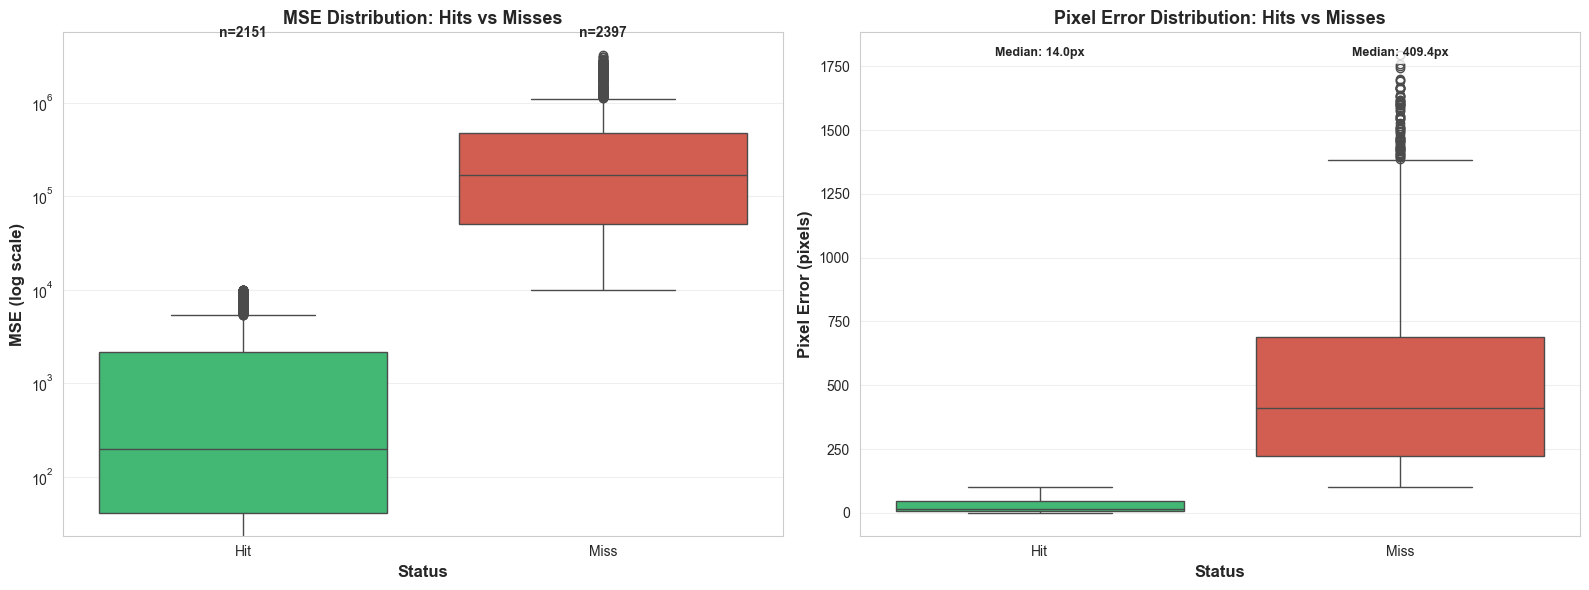


PERCENTAGE BREAKDOWN

Total Steps: 4548
Estimated Hits: 2151 (47.3%)
Misses: 2397 (52.7%)

Among Misses:
  Near Misses (< 200px off): 509 (21.2%)
  Complete Misses (≥ 200px off): 1888 (78.8%)



In [29]:
# Box plot comparison of MSE for hits vs misses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data with labels
step_df['hit_status'] = step_df['estimated_hit'].map({1: 'Hit', 0: 'Miss'})

# 1. Box plot for MSE (with log scale due to large range)
ax1 = axes[0]
sns.boxplot(data=step_df, x='hit_status', y='mse', ax=ax1, palette={'Hit': '#2ecc71', 'Miss': '#e74c3c'})
ax1.set_yscale('log')
ax1.set_xlabel('Status', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE (log scale)', fontsize=12, fontweight='bold')
ax1.set_title('MSE Distribution: Hits vs Misses', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add counts
for i, status in enumerate(['Hit', 'Miss']):
    count = len(step_df[step_df['hit_status'] == status])
    ax1.text(i, ax1.get_ylim()[1] * 0.9, f'n={count}', ha='center', fontsize=10, fontweight='bold')

# 2. Box plot for Pixel Error
ax2 = axes[1]
sns.boxplot(data=step_df, x='hit_status', y='pixel_error', ax=ax2, palette={'Hit': '#2ecc71', 'Miss': '#e74c3c'})
ax2.set_xlabel('Status', fontsize=12, fontweight='bold')
ax2.set_ylabel('Pixel Error (pixels)', fontsize=12, fontweight='bold')
ax2.set_title('Pixel Error Distribution: Hits vs Misses', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add median values
for i, status in enumerate(['Hit', 'Miss']):
    median_val = step_df[step_df['hit_status'] == status]['pixel_error'].median()
    ax2.text(i, ax2.get_ylim()[1] * 0.95, f'Median: {median_val:.1f}px', ha='center', fontsize=9, fontweight='bold', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('mse_boxplot_hit_vs_miss.png', dpi=300, bbox_inches='tight')
plt.show()

# Show percentage breakdown
print("\n" + "="*80)
print("PERCENTAGE BREAKDOWN")
print("="*80)
total_steps = len(step_df)
hit_count = len(hits_df)
miss_count = len(misses_df)

print(f"\nTotal Steps: {total_steps}")
print(f"Estimated Hits: {hit_count} ({hit_count/total_steps*100:.1f}%)")
print(f"Misses: {miss_count} ({miss_count/total_steps*100:.1f}%)")

# Near misses (misses with low MSE)
near_misses = misses_df[misses_df['pixel_error'] < 200]
complete_misses = misses_df[misses_df['pixel_error'] >= 200]

print(f"\nAmong Misses:")
print(f"  Near Misses (< 200px off): {len(near_misses)} ({len(near_misses)/miss_count*100:.1f}%)")
print(f"  Complete Misses (≥ 200px off): {len(complete_misses)} ({len(complete_misses)/miss_count*100:.1f}%)")
print("\n" + "="*80)
